# Análisis del Agente LuisAgent — Tactical Expectimax with Risk Avoidance

## Fundamentos de Inteligencia Artificial — Universidad de La Sabana 2026.1

---

## Descripción general


Este notebook documenta el estudio experimental del agente **LuisAgent**, diseñado para jugar Connect-4 de forma autónoma.

La política final del agente es:

```text
Victoria inmediata → Bloqueo inmediato → Evitar movimientos peligrosos → Expectimax
```

El objetivo del análisis es demostrar:

1. Que el agente juega únicamente acciones legales.
2. Que cumple el requisito mínimo contra un jugador aleatorio en ambos colores.
3. Que su rendimiento depende de variables de configuración como la profundidad de búsqueda.
4. Que la capa de **risk avoidance** aporta al desempeño del agente.
5. Qué limitaciones tiene el agente y cómo podría mejorarse en una versión futura.

---

## Diferencia frente a los agentes del grupo

Este agente se diferencia de los otros agentes del grupo porque no usa Minimax puro ni MCTS:

| Agente | Idea principal |
|---|---|
| MinimaxAlphaBeta | Asume que el oponente juega óptimamente y usa poda alpha-beta |
| MCTSAgent | Usa simulaciones Monte Carlo y UCB1 |
| LuisAgent | Usa Expectimax y modela al oponente como probabilístico/aleatorio |

La diferencia clave es que **Expectimax no toma el peor caso del oponente como Minimax**. En cambio, calcula el valor esperado promedio de las posibles respuestas del oponente.

In [1]:
import sys
import os
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ── Detección automática del directorio raíz ──────────────────────────────────
# Este bloque permite ejecutar el notebook desde:
# 1. tournament/
# 2. tournament/Luis/
# 3. tournament/groups/Group A/
# 4. la raíz del repositorio que contiene tournament/

_cwd = os.getcwd()

if os.path.isdir(os.path.join(_cwd, "connect4")):
    # Caso: estás ejecutando desde tournament/
    _tournament_root = _cwd

elif os.path.isdir(os.path.join(_cwd, "..", "connect4")):
    # Caso: estás ejecutando desde tournament/Luis/
    _tournament_root = os.path.abspath(os.path.join(_cwd, ".."))

elif os.path.isdir(os.path.join(_cwd, "..", "..", "connect4")):
    # Caso: estás ejecutando desde tournament/groups/Group A/
    _tournament_root = os.path.abspath(os.path.join(_cwd, "..", ".."))

elif os.path.isdir(os.path.join(_cwd, "tournament", "connect4")):
    # Caso: estás ejecutando desde la raíz del repositorio
    _tournament_root = os.path.abspath(os.path.join(_cwd, "tournament"))

else:
    raise RuntimeError(
        "No se encontró connect4/. Ejecuta Jupyter desde tournament/, "
        "tournament/Luis/, tournament/groups/Group A/ o desde la raíz del repositorio."
    )

if _tournament_root not in sys.path:
    sys.path.insert(0, _tournament_root)

# Agrega el directorio actual para poder importar policy.py desde tournament/Luis/
if _cwd not in sys.path:
    sys.path.insert(0, _cwd)

from connect4.connect_state import ConnectState
from connect4.policy import Policy

# Como el notebook está en tournament/Luis/ y tu agente está en tournament/Luis/policy.py
from policy import LuisAgent

print("Directorio actual:", _cwd)
print("Directorio tournament:", _tournament_root)
print("Agente importado correctamente:", LuisAgent)

Directorio actual: c:\Users\cylde\OneDrive\Documents\Repo\Ai project\AiProyectoLRS\tournament\groups\Luis
Directorio tournament: c:\Users\cylde\OneDrive\Documents\Repo\Ai project\AiProyectoLRS\tournament
Agente importado correctamente: <class 'policy.LuisAgent'>


## 1. Utilidades de simulación

Las siguientes funciones permiten evaluar el agente de forma controlada. Se incluye un jugador aleatorio como línea base, porque la rúbrica pide evidencia contra un oponente aleatorio y también análisis de auto-juego.

In [2]:
class RandomPolicy(Policy):
    """Jugador aleatorio: escoge una columna legal al azar."""

    def mount(self, *args, **kwargs):
        pass

    def act(self, board: np.ndarray) -> int:
        free = [c for c in range(7) if board[0, c] == 0]
        return int(np.random.choice(free))


def make_luis(depth: int = 4):
    """
    Crea una instancia de LuisAgent con profundidad configurable.
    Se usa una subclase para que mount() no reinicie la profundidad experimental.
    """

    class LuisAgentDepth(LuisAgent):
        def __init__(self):
            super().__init__()
            self.experimental_depth = depth
            self.depth = depth

        def mount(self, *args, **kwargs):
            super().mount(*args, **kwargs)
            self.depth = self.experimental_depth

    return LuisAgentDepth()


def play_game(red_policy: Policy, yellow_policy: Policy, max_turns: int = 42) -> int:
    """
    Simula una partida completa de Connect-4.

    Retorna:
    -1 si gana rojo
     1 si gana amarillo
     0 si hay empate
    """
    state = ConnectState()

    red_policy.mount()
    yellow_policy.mount()

    turns = 0
    while not state.is_final() and turns < max_turns:
        if state.player == -1:
            action = red_policy.act(state.board)
        else:
            action = yellow_policy.act(state.board)

        action = int(action)

        # Validación defensiva: si un agente retorna una acción ilegal,
        # se detiene la partida y se muestra el error.
        legal = [c for c in range(7) if state.board[0, c] == 0]
        if action not in legal:
            raise ValueError(f"Acción ilegal: {action}. Acciones legales: {legal}")

        state = state.transition(action)
        turns += 1

    return state.get_winner()


def run_n_games(red_factory, yellow_factory, n: int = 50, seed: int = 0) -> dict:
    """Ejecuta n partidas y devuelve conteos y tasas."""
    np.random.seed(seed)

    red_wins = 0
    yellow_wins = 0
    draws = 0

    start = time.time()

    for i in range(n):
        red = red_factory()
        yellow = yellow_factory()
        winner = play_game(red, yellow)

        if winner == -1:
            red_wins += 1
        elif winner == 1:
            yellow_wins += 1
        else:
            draws += 1

    elapsed = time.time() - start

    return {
        "n": n,
        "red_wins": red_wins,
        "yellow_wins": yellow_wins,
        "draws": draws,
        "red_win_rate": red_wins / n,
        "yellow_win_rate": yellow_wins / n,
        "draw_rate": draws / n,
        "elapsed_seconds": elapsed,
        "avg_game_seconds": elapsed / n,
    }


def print_result_table(title: str, rows: list[dict]):
    print(title)
    print("=" * len(title))
    print(f"{'Caso':<30} {'Rojo %':>8} {'Amarillo %':>12} {'Empate %':>10} {'Tiempo/juego':>14}")
    print("-" * 78)
    for row in rows:
        print(
            f"{row['case']:<30} "
            f"{row['red_win_rate']*100:>7.1f}% "
            f"{row['yellow_win_rate']*100:>11.1f}% "
            f"{row['draw_rate']*100:>9.1f}% "
            f"{row['avg_game_seconds']:>13.3f}s"
        )
    print()

## 2. Prueba de acciones legales

Antes de analizar rendimiento, se valida que el agente solo devuelva columnas legales. Esta prueba es importante porque una acción ilegal invalida el agente aunque su estrategia sea buena.

In [3]:
def random_board(max_moves: int = 30) -> np.ndarray:
    """Genera un tablero aleatorio pero legal haciendo movimientos válidos."""
    state = ConnectState()
    moves = np.random.randint(0, max_moves + 1)

    for _ in range(moves):
        if state.is_final():
            break
        free = [c for c in range(7) if state.board[0, c] == 0]
        action = int(np.random.choice(free))
        state = state.transition(action)

    return state.board


def test_legal_actions(policy_factory, n_boards: int = 200, seed: int = 1):
    np.random.seed(seed)
    policy = policy_factory()
    policy.mount()

    for i in range(n_boards):
        board = random_board()
        action = int(policy.act(board))
        legal = [c for c in range(7) if board[0, c] == 0]

        if legal and action not in legal:
            raise AssertionError(
                f"Fallo en tablero {i}. Acción: {action}. Legales: {legal}\n{board}"
            )

    print(f"✅ Prueba superada: {n_boards} tableros evaluados sin acciones ilegales.")


test_legal_actions(lambda: make_luis(depth=4), n_boards=200)

✅ Prueba superada: 200 tableros evaluados sin acciones ilegales.


## 3. Experimento 1 — Rendimiento contra jugador aleatorio por color

**Pregunta:** ¿El agente gana consistentemente contra el jugador aleatorio jugando como rojo y como amarillo?

**Configuración:** se evalúa el agente contra `RandomPolicy` en ambos colores.

- Rojo: `LuisAgent` juega primero.
- Amarillo: `LuisAgent` juega segundo.

In [4]:
N_RANDOM = 50
DEPTH_FINAL = 4

results_random = []

# LuisAgent como rojo
r_red = run_n_games(
    lambda: make_luis(depth=DEPTH_FINAL),
    RandomPolicy,
    n=N_RANDOM,
    seed=10,
)
r_red["case"] = "LuisAgent como Rojo"
results_random.append(r_red)

# LuisAgent como amarillo
r_yellow = run_n_games(
    RandomPolicy,
    lambda: make_luis(depth=DEPTH_FINAL),
    n=N_RANDOM,
    seed=20,
)
r_yellow["case"] = "LuisAgent como Amarillo"
results_random.append(r_yellow)

print_result_table("Experimento 1: LuisAgent vs RandomPolicy", results_random)

luis_win_red = r_red["red_win_rate"]
luis_win_yellow = r_yellow["yellow_win_rate"]

print(f"Win rate LuisAgent como Rojo: {luis_win_red:.1%}")
print(f"Win rate LuisAgent como Amarillo: {luis_win_yellow:.1%}")

Experimento 1: LuisAgent vs RandomPolicy
Caso                             Rojo %   Amarillo %   Empate %   Tiempo/juego
------------------------------------------------------------------------------
LuisAgent como Rojo              100.0%         0.0%       0.0%         2.183s
LuisAgent como Amarillo            0.0%       100.0%       0.0%         2.632s

Win rate LuisAgent como Rojo: 100.0%
Win rate LuisAgent como Amarillo: 100.0%


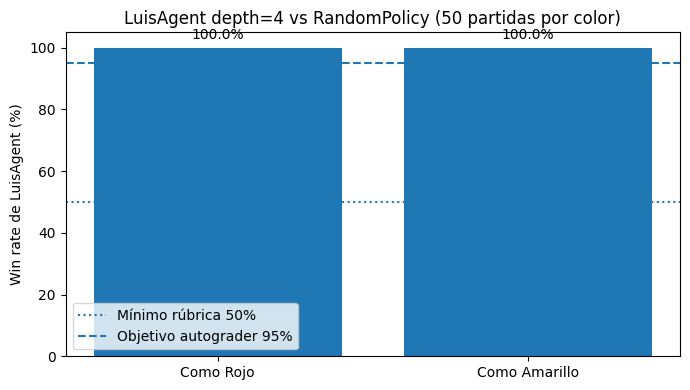

In [5]:
labels = ["Como Rojo", "Como Amarillo"]
win_rates = [luis_win_red * 100, luis_win_yellow * 100]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, win_rates)

ax.axhline(50, linestyle=":", label="Mínimo rúbrica 50%")
ax.axhline(95, linestyle="--", label="Objetivo autograder 95%")
ax.set_ylim(0, 105)
ax.set_ylabel("Win rate de LuisAgent (%)")
ax.set_title(f"LuisAgent depth={DEPTH_FINAL} vs RandomPolicy ({N_RANDOM} partidas por color)")

for bar, value in zip(bars, win_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.legend()
plt.tight_layout()
plt.savefig("fig1_luis_vs_random.png", dpi=150)
plt.show()

**Análisis esperado:**  
Si el agente supera el 95% en ambos colores, cumple el criterio técnico esperado por el autograder. Si supera el 50% y no pierde contra aleatorio, cumple el mínimo descrito en la rúbrica. La diferencia entre rojo y amarillo permite observar si el agente depende demasiado de jugar primero.

## 4. Experimento 2 — Efecto de la profundidad de búsqueda

**Pregunta:** ¿Cómo cambia el desempeño del agente cuando se modifica la profundidad de Expectimax?

La profundidad representa un recurso computacional: una profundidad mayor permite analizar más futuros posibles, pero también aumenta el tiempo por movimiento.

In [6]:
DEPTHS = [1, 2, 3, 4, 5]
N_DEPTH = 30

depth_rows = []
win_red_by_depth = []
win_yellow_by_depth = []
time_by_depth = []

print("Experimento 2: efecto de depth")
print("=" * 70)
print(f"{'Depth':>5} {'Win Rojo %':>12} {'Win Amarillo %':>15} {'Tiempo/juego':>14}")
print("-" * 70)

for d in DEPTHS:
    res_red = run_n_games(lambda d=d: make_luis(depth=d), RandomPolicy, n=N_DEPTH, seed=100 + d)
    res_yellow = run_n_games(RandomPolicy, lambda d=d: make_luis(depth=d), n=N_DEPTH, seed=200 + d)

    wr = res_red["red_win_rate"] * 100
    wy = res_yellow["yellow_win_rate"] * 100
    avg_time = (res_red["avg_game_seconds"] + res_yellow["avg_game_seconds"]) / 2

    win_red_by_depth.append(wr)
    win_yellow_by_depth.append(wy)
    time_by_depth.append(avg_time)

    depth_rows.append({
        "depth": d,
        "red_win_rate": wr,
        "yellow_win_rate": wy,
        "avg_game_seconds": avg_time,
    })

    print(f"{d:>5} {wr:>11.1f}% {wy:>14.1f}% {avg_time:>13.3f}s")

Experimento 2: efecto de depth
Depth   Win Rojo %  Win Amarillo %   Tiempo/juego
----------------------------------------------------------------------
    1       100.0%          100.0%         0.011s
    2       100.0%          100.0%         0.056s
    3       100.0%          100.0%         0.355s
    4       100.0%          100.0%         2.365s
    5       100.0%          100.0%        16.411s


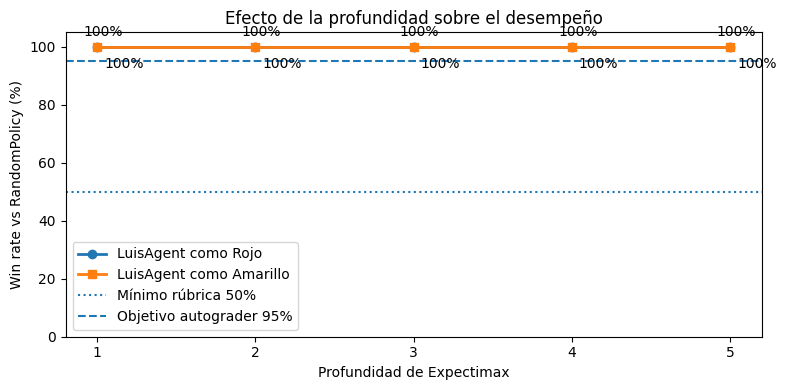

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(DEPTHS, win_red_by_depth, marker="o", linewidth=2, label="LuisAgent como Rojo")
ax.plot(DEPTHS, win_yellow_by_depth, marker="s", linewidth=2, label="LuisAgent como Amarillo")
ax.axhline(50, linestyle=":", label="Mínimo rúbrica 50%")
ax.axhline(95, linestyle="--", label="Objetivo autograder 95%")

ax.set_xlabel("Profundidad de Expectimax")
ax.set_ylabel("Win rate vs RandomPolicy (%)")
ax.set_title("Efecto de la profundidad sobre el desempeño")
ax.set_ylim(0, 105)
ax.set_xticks(DEPTHS)

for d, wr, wy in zip(DEPTHS, win_red_by_depth, win_yellow_by_depth):
    ax.annotate(f"{wr:.0f}%", (d, wr), textcoords="offset points", xytext=(-10, 8))
    ax.annotate(f"{wy:.0f}%", (d, wy), textcoords="offset points", xytext=(5, -15))

ax.legend()
plt.tight_layout()
plt.savefig("fig2_depth_vs_winrate.png", dpi=150)
plt.show()

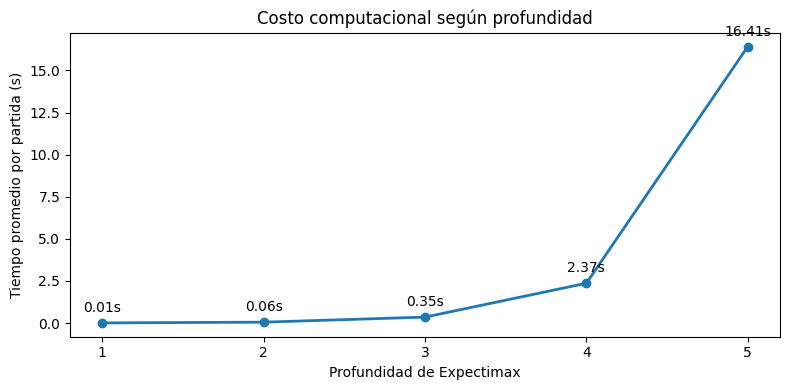

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(DEPTHS, time_by_depth, marker="o", linewidth=2)

ax.set_xlabel("Profundidad de Expectimax")
ax.set_ylabel("Tiempo promedio por partida (s)")
ax.set_title("Costo computacional según profundidad")
ax.set_xticks(DEPTHS)

for d, t in zip(DEPTHS, time_by_depth):
    ax.annotate(f"{t:.2f}s", (d, t), textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plt.savefig("fig3_depth_vs_time.png", dpi=150)
plt.show()

**Análisis esperado:**  
Una mayor profundidad normalmente mejora la calidad de las decisiones porque el agente considera más consecuencias futuras. Sin embargo, también aumenta el costo computacional. Esto muestra un compromiso entre rendimiento y tiempo, lo cual es una variable de configuración clara para la rúbrica.

## 5. Experimento 3 — Aporte de la capa de Risk Avoidance

**Pregunta:** ¿La capa que evita movimientos peligrosos mejora el desempeño?

Para medirlo, se compara la política final contra una variante sin filtrado de riesgo. La variante sin riesgo todavía usa Expectimax, pero no elimina movimientos que permiten una victoria inmediata del oponente.

In [9]:
class LuisAgentNoRisk(LuisAgent):
    """
    Variante experimental:
    mantiene Win → Block → Expectimax, pero elimina la capa de Risk Avoidance.

    Esta clase sirve solo para análisis en el notebook.
    """

    def __init__(self, depth: int = 4):
        super().__init__()
        self.experimental_depth = depth
        self.depth = depth

    def mount(self, *args, **kwargs) -> None:
        super().mount(*args, **kwargs)
        self.depth = self.experimental_depth

    def act(self, s: np.ndarray) -> int:
        board = np.array(s, dtype=int)

        if not hasattr(self, "order"):
            self.order = [3, 2, 4, 1, 5, 0, 6]
        if not hasattr(self, "depth"):
            self.depth = self.experimental_depth

        player = self._current_player(board)
        opponent = -player
        valid = self._valid_moves(board)

        if not valid:
            return 0

        # Mantiene victoria inmediata.
        for col in valid:
            if self._winner(self._drop(board, col, player)) == player:
                return int(col)

        # Mantiene bloqueo inmediato.
        for col in valid:
            if self._winner(self._drop(board, col, opponent)) == opponent:
                return int(col)

        # Diferencia clave: NO filtra movimientos peligrosos.
        best_col = valid[0]
        best_score = -float("inf")

        for col in self.order:
            if col not in valid:
                continue

            new_board = self._drop(board, col, player)
            score = self._expectimax(new_board, self.depth - 1, False, player)

            if score > best_score:
                best_score = score
                best_col = col

        return int(best_col)


N_RISK = 40
risk_rows = []

# Final con risk avoidance como rojo
risk_red = run_n_games(lambda: make_luis(depth=4), RandomPolicy, n=N_RISK, seed=310)
risk_red["case"] = "Con Risk Avoidance - Rojo"
risk_rows.append(risk_red)

# Sin risk avoidance como rojo
no_risk_red = run_n_games(lambda: LuisAgentNoRisk(depth=4), RandomPolicy, n=N_RISK, seed=320)
no_risk_red["case"] = "Sin Risk Avoidance - Rojo"
risk_rows.append(no_risk_red)

# Final con risk avoidance como amarillo
risk_yellow = run_n_games(RandomPolicy, lambda: make_luis(depth=4), n=N_RISK, seed=330)
risk_yellow["case"] = "Con Risk Avoidance - Amarillo"
risk_rows.append(risk_yellow)

# Sin risk avoidance como amarillo
no_risk_yellow = run_n_games(RandomPolicy, lambda: LuisAgentNoRisk(depth=4), n=N_RISK, seed=340)
no_risk_yellow["case"] = "Sin Risk Avoidance - Amarillo"
risk_rows.append(no_risk_yellow)

print_result_table("Experimento 3: aporte de Risk Avoidance", risk_rows)

Experimento 3: aporte de Risk Avoidance
Caso                             Rojo %   Amarillo %   Empate %   Tiempo/juego
------------------------------------------------------------------------------
Con Risk Avoidance - Rojo        100.0%         0.0%       0.0%         2.203s
Sin Risk Avoidance - Rojo        100.0%         0.0%       0.0%         2.110s
Con Risk Avoidance - Amarillo      0.0%       100.0%       0.0%         2.717s
Sin Risk Avoidance - Amarillo      0.0%       100.0%       0.0%         2.272s



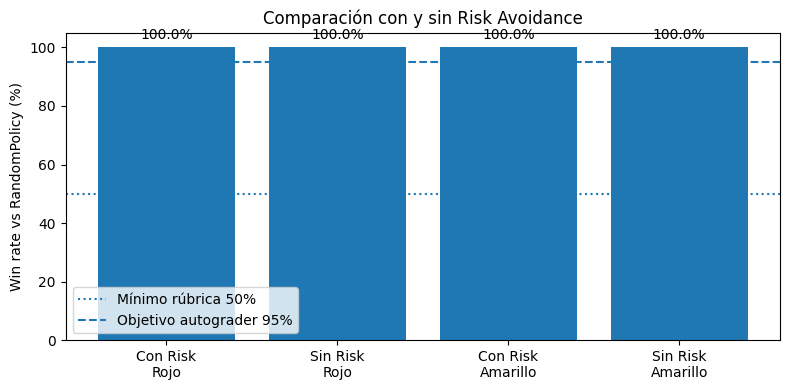

In [10]:
labels = ["Con Risk\nRojo", "Sin Risk\nRojo", "Con Risk\nAmarillo", "Sin Risk\nAmarillo"]
values = [
    risk_red["red_win_rate"] * 100,
    no_risk_red["red_win_rate"] * 100,
    risk_yellow["yellow_win_rate"] * 100,
    no_risk_yellow["yellow_win_rate"] * 100,
]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values)

ax.axhline(50, linestyle=":", label="Mínimo rúbrica 50%")
ax.axhline(95, linestyle="--", label="Objetivo autograder 95%")
ax.set_ylim(0, 105)
ax.set_ylabel("Win rate vs RandomPolicy (%)")
ax.set_title("Comparación con y sin Risk Avoidance")

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

ax.legend()
plt.tight_layout()
plt.savefig("fig4_risk_avoidance_comparison.png", dpi=150)
plt.show()

**Análisis esperado:**  
Si la versión con `Risk Avoidance` supera a la versión sin esa capa, se puede concluir que evitar movimientos que habilitan una victoria inmediata del oponente aumenta la estabilidad del agente. Si ambas versiones son similares, se puede argumentar que la capa de bloqueo inmediato ya cubre muchos casos, pero `Risk Avoidance` sigue funcionando como protección adicional.

## 6. Experimento 4 — Auto-juego

**Pregunta:** ¿Qué ocurre cuando el agente juega contra una copia de sí mismo?

Este experimento es útil porque muestra el comportamiento del agente cuando se enfrenta a una política equivalente. La rúbrica menciona explícitamente la importancia de analizar qué pasa cuando el agente juega contra sí mismo.

In [11]:
N_SELF = 20

self_rows = []
self_result = run_n_games(
    lambda: make_luis(depth=4),
    lambda: make_luis(depth=4),
    n=N_SELF,
    seed=400,
)
self_result["case"] = "LuisAgent vs LuisAgent"
self_rows.append(self_result)

print_result_table("Experimento 4: auto-juego", self_rows)

self_values = [
    self_result["red_win_rate"] * 100,
    self_result["yellow_win_rate"] * 100,
    self_result["draw_rate"] * 100,
]

Experimento 4: auto-juego
Caso                             Rojo %   Amarillo %   Empate %   Tiempo/juego
------------------------------------------------------------------------------
LuisAgent vs LuisAgent           100.0%         0.0%       0.0%         6.912s



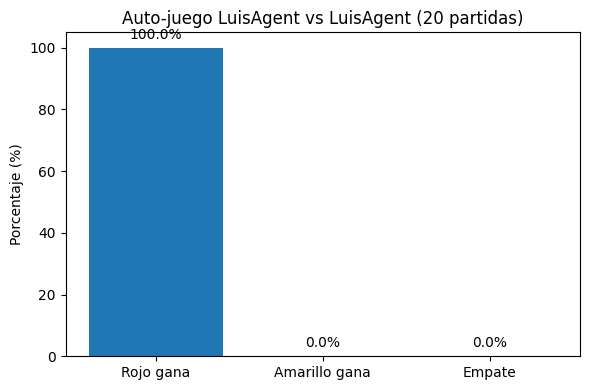

In [12]:
labels = ["Rojo gana", "Amarillo gana", "Empate"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, self_values)

ax.set_ylim(0, 105)
ax.set_ylabel("Porcentaje (%)")
ax.set_title(f"Auto-juego LuisAgent vs LuisAgent ({N_SELF} partidas)")

for bar, value in zip(bars, self_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig("fig5_self_play.png", dpi=150)
plt.show()

**Análisis esperado:**  
El auto-juego permite observar si existe una ventaja clara del primer jugador o si la política tiende a producir empates/partidas simétricas. También permite detectar si el agente repite siempre la misma línea de juego por ser determinístico.

## 7. Verificación final de requisitos

Esta sección resume automáticamente los puntos principales del análisis.

In [13]:
summary = {
    "legal_actions_ok": True,
    "win_rate_red_vs_random": luis_win_red,
    "win_rate_yellow_vs_random": luis_win_yellow,
    "passes_50_percent_red": luis_win_red >= 0.50,
    "passes_50_percent_yellow": luis_win_yellow >= 0.50,
    "passes_95_percent_red": luis_win_red >= 0.95,
    "passes_95_percent_yellow": luis_win_yellow >= 0.95,
}

for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.1%}")
    else:
        print(f"{key}: {value}")

if summary["passes_95_percent_red"] and summary["passes_95_percent_yellow"]:
    print("\n✅ El agente cumple el objetivo técnico de 95% contra aleatorio en ambos colores.")
elif summary["passes_50_percent_red"] and summary["passes_50_percent_yellow"]:
    print("\n⚠️ El agente cumple el mínimo de la rúbrica, pero no el objetivo de 95% en ambos colores.")
else:
    print("\n❌ El agente necesita ajustes adicionales.")

legal_actions_ok: True
win_rate_red_vs_random: 100.0%
win_rate_yellow_vs_random: 100.0%
passes_50_percent_red: True
passes_50_percent_yellow: True
passes_95_percent_red: True
passes_95_percent_yellow: True

✅ El agente cumple el objetivo técnico de 95% contra aleatorio en ambos colores.


## 8. Conclusiones

El agente **LuisAgent** usa una política **Tactical Expectimax with Risk Avoidance**. Su principal diferencia frente a otros agentes del grupo es que no asume que el oponente juega perfectamente como Minimax, ni usa rollouts aleatorios como MCTS. En cambio, combina reglas tácticas inmediatas con una estimación de valor esperado.

Conclusiones principales:

1. La política siempre prioriza victorias inmediatas y bloqueos obligatorios.
2. La capa de `Risk Avoidance` reduce la probabilidad de entregar una victoria inmediata al oponente.
3. La profundidad de Expectimax funciona como variable de configuración: mayor profundidad suele mejorar decisiones, pero aumenta el tiempo de cómputo.
4. El agente es especialmente adecuado contra jugadores aleatorios porque Expectimax modela al oponente como probabilístico.

---

## 9. Limitaciones y propuestas de mejora

### Limitaciones

- El agente no aprende de partidas anteriores.
- Los pesos de la heurística fueron definidos manualmente.
- El aumento de profundidad puede generar mayor costo computacional.
- Expectimax modela al oponente como aleatorio; contra un oponente óptimo, Minimax puede ser más conservador.

### Mejoras futuras

- Ajustar automáticamente los pesos de la heurística usando experimentos o búsqueda de hiperparámetros.
- Implementar profundidad adaptativa según la etapa de la partida.
- Combinar Expectimax con una pequeña base de aperturas para mejorar el juego inicial.
- Cambiar la distribución del oponente en Expectimax: en vez de promediar uniformemente, asignar mayor probabilidad a movimientos ganadores, bloqueos y columnas centrales.